# Assignment: Video Quality Inference

To this point in the class, you have learned various techniques for leading and analyzing packet captures of various types, generating features from those packet captures, and training and evaluating models using those features.

In this assignment, you will put all of this together, using a network traffic trace to train a model to automatically infer video quality of experience from a labeled traffic trace.

## Part 1: Warmup

The first part of this assignment builds directly on the hands-on activities but extends them slightly.

### Extract Features from the Network Traffic

Load the `netflix.pcap` file, which is a packet trace that includes network traffic. 


In [4]:
from scapy.all import DNS, DNSRR, DNSQR, IP, rdpcap, wrpcap
import pandas as pd
import numpy as np


netflix_pcap_file = 'netflix.pcap'

packets = rdpcap(netflix_pcap_file)
print (packets)

<netflix.pcap: TCP:141143 UDP:232 ICMP:16 Other:80>


### Identifying the Service Type

Use the DNS traffic to filter the packet trace for Netflix traffic.

In [5]:
netflix_ips = set()
netflix_keywords = (b"netflix", b"nflx", b"nflxvideo")

for pkt in packets:
    if pkt.haslayer(DNS) and pkt[DNS].qr == 1:
        dns = pkt[DNS]
        raw_dns = bytes(dns).lower()

        if any(keyword in raw_dns for keyword in netflix_keywords):
            for i in range(dns.ancount):
                answer = dns.an[i]

                if isinstance(answer, DNSRR) and answer.type == 1:
                    ip_address = answer.rdata

                    if isinstance(ip_address, bytes):
                        ip_address = ip_address.decode()

                    netflix_ips.add(str(ip_address))

print("Identified Netflix IPs:", netflix_ips)

netflix_packets = [
    pkt for pkt in packets
    if pkt.haslayer(IP)
    and (
        pkt[IP].src in netflix_ips
        or pkt[IP].dst in netflix_ips
    )
]

print("Total packets in trace:", len(packets))
print("Netflix packets:", len(netflix_packets))

Identified Netflix IPs: {'198.38.120.130', '198.38.120.153', '52.19.39.146', '198.38.120.162', '52.48.148.78', '198.38.120.166', '34.252.77.54', '52.48.8.150', '52.210.133.255', '52.208.128.101', '198.38.120.137', '198.38.120.167', '198.38.120.164', '52.210.19.176', '198.38.120.134'}
Total packets in trace: 141471
Netflix packets: 138633


### Generate Statistics

Generate statistics and features for the Netflix traffic flows. Use the `netml` library or any other technique that you choose to generate a set of features that you think would be good features for your model. 

In [8]:
import numpy as np
import pandas as pd
from scapy.all import IP

CLIENT_IP = "192.168.43.72"
WINDOW_SIZE = 10

records = []

for pkt in netflix_packets:
    if not pkt.haslayer(IP):
        continue

    src_ip = pkt[IP].src
    dst_ip = pkt[IP].dst

    if dst_ip == CLIENT_IP:
        direction = "inbound"
    elif src_ip == CLIENT_IP:
        direction = "outbound"
    else:
        continue

    records.append({
        "time": float(pkt.time),
        "size": len(pkt),
        "direction": direction
    })

df_pkts = (
    pd.DataFrame(records)
    .sort_values("time")
    .reset_index(drop=True)
    .copy()
)

if df_pkts.empty:
    raise ValueError(
        "No Netflix packets involving the client IP were found."
    )

t0 = df_pkts["time"].min()

df_pkts.loc[:, "window"] = (
    (df_pkts["time"] - t0) // WINDOW_SIZE
).astype(int)

rows = []

for win_idx in range(df_pkts["window"].max() + 1):
    group = df_pkts[df_pkts["window"] == win_idx]

    inbound = group[group["direction"] == "inbound"]
    outbound = group[group["direction"] == "outbound"]

    inbound_sizes = inbound["size"].to_numpy()
    outbound_sizes = outbound["size"].to_numpy()

    inbound_times = inbound["time"].to_numpy()

    inbound_iats = (
        np.diff(inbound_times)
        if len(inbound_times) > 1
        else np.array([])
    )

    rows.append({
        "window": win_idx,
        "time_seconds": win_idx * WINDOW_SIZE,

        "inbound_packet_count": len(inbound),
        "outbound_packet_count": len(outbound),

        "inbound_byte_count":
            inbound_sizes.sum() if len(inbound_sizes) else 0,

        "outbound_byte_count":
            outbound_sizes.sum() if len(outbound_sizes) else 0,

        "inbound_throughput_bytes_per_sec":
            inbound_sizes.sum() / WINDOW_SIZE
            if len(inbound_sizes) else 0,

        "outbound_throughput_bytes_per_sec":
            outbound_sizes.sum() / WINDOW_SIZE
            if len(outbound_sizes) else 0,

        "packet_size_mean":
            inbound_sizes.mean() if len(inbound_sizes) else 0,

        "packet_size_std":
            inbound_sizes.std() if len(inbound_sizes) else 0,

        "packet_size_min":
            inbound_sizes.min() if len(inbound_sizes) else 0,

        "packet_size_max":
            inbound_sizes.max() if len(inbound_sizes) else 0,

        "iat_mean":
            inbound_iats.mean() if len(inbound_iats) else 0,

        "iat_std":
            inbound_iats.std() if len(inbound_iats) else 0,

        "iat_min":
            inbound_iats.min() if len(inbound_iats) else 0,

        "iat_max":
            inbound_iats.max() if len(inbound_iats) else 0
    })

samp_df = pd.DataFrame(rows)

print("Feature matrix shape:", samp_df.shape)
display(samp_df.head())

X_part1 = samp_df.drop(columns=["window", "time_seconds"])

print("Traffic feature matrix shape:", X_part1.shape)

Feature matrix shape: (50, 16)


,window,time_seconds,inbound_packet_count,outbound_packet_count,inbound_byte_count,outbound_byte_count,inbound_throughput_bytes_per_sec,outbound_throughput_bytes_per_sec,packet_size_mean,packet_size_std,packet_size_min,packet_size_max,iat_mean,iat_std,iat_min,iat_max
0,0,0,262,309,39418,30568,3941.8,3056.8,150.450382,59.996465,66,200,0.035178,0.102100,9.536743e-07,1.366147
1,1,10,291,267,48649,22781,4864.9,2278.1,167.178694,56.566134,66,200,0.034317,0.062971,6.198883e-06,0.673235
2,2,20,317,235,59564,19239,5956.4,1923.9,187.899054,37.992477,66,200,0.031486,0.044509,9.536743e-07,0.551145
3,3,30,243,211,47662,17565,4766.2,1756.5,196.139918,22.413183,66,200,0.040501,0.070907,4.291534e-05,0.707592
4,4,40,262,179,52266,11814,5226.6,1181.4,199.488550,8.262734,66,200,0.038191,0.056166,2.319813e-04,0.562152


Traffic feature matrix shape: (50, 14)


**Write a brief justification for the features that you have chosen.**

I selected packet counts, byte counts, throughput, packet-size statistics, and inter-arrival-time (IAT) statistics because they capture the fundamental characteristics of encrypted Adaptive Bitrate (ABR) video streams without requiring payload inspection. Inbound/outbound counts reflect traffic asymmetry, while inbound throughput acts as a direct proxy for encoded video bitrate (higher resolutions demand higher data rates). Packet-size statistics capture payload saturation (higher resolutions push larger packets close to path MTU), and IAT statistics quantify the burstiness and ON/OFF cycle of video chunk downloads. Computing these over fixed 10-second windows allows the model to track dynamic resolution switches throughout a session. Finally, time indices (window, time_seconds) are retained strictly for session visualization and are excluded from the model feature matrix to prevent metadata leakage.

### Inferring Segment downloads

In addition to the features that you could generate using the `netml` library or similar, add to your feature vector a "segment downloads rate" feature, which indicates the number of video segments downloaded for a given time window.

Note: If you are using the `netml` library, generating features with `SAMP` style options may be useful, as this option gives you time windows, and you can then simply add the segment download rate to that existing dataframe.

In [9]:
IDLE_GAP_THRESHOLD = 0.5  
WINDOW_SIZE = 10

t0_global = df_pkts["time"].min()

inbound_ts = np.array(
    sorted(
        float(pkt.time)
        for pkt in netflix_packets
        if pkt.haslayer(IP)
        and pkt[IP].dst == CLIENT_IP
    )
)

if len(inbound_ts) > 0:
    gaps = np.diff(inbound_ts)

    segment_start_mask = np.concatenate([
        [True],
        gaps > IDLE_GAP_THRESHOLD
    ])

    segment_start_times = inbound_ts[segment_start_mask]

    window_idx = (
        (segment_start_times - t0_global) // WINDOW_SIZE
    ).astype(int)

    segment_counts = np.bincount(
        window_idx,
        minlength=len(samp_df)
    )[:len(samp_df)]

else:
    segment_start_times = np.array([])
    segment_counts = np.zeros(len(samp_df), dtype=int)

segment_df = pd.DataFrame({
    "window": samp_df["window"],
    "segment_download_count": segment_counts,
    "segment_download_rate": segment_counts / WINDOW_SIZE
})

print(
    f"Detected {len(segment_start_times)} estimated "
    f"segment downloads across {len(segment_df)} windows"
)

display(segment_df.head())

features_df = samp_df.merge(
    segment_df,
    on="window",
    how="left"
)

X_part1 = features_df.drop(
    columns=[
        "window",
        "time_seconds",
        "segment_download_count"
    ]
)

print("Final feature matrix shape:", X_part1.shape)
display(features_df.head())

Detected 138 estimated segment downloads across 50 windows


,window,segment_download_count,segment_download_rate
0,0,3,0.3
1,1,1,0.1
2,2,2,0.2
3,3,1,0.1
4,4,2,0.2


Final feature matrix shape: (50, 15)


,window,time_seconds,inbound_packet_count,outbound_packet_count,inbound_byte_count,outbound_byte_count,inbound_throughput_bytes_per_sec,outbound_throughput_bytes_per_sec,packet_size_mean,packet_size_std,packet_size_min,packet_size_max,iat_mean,iat_std,iat_min,iat_max,segment_download_count,segment_download_rate
0,0,0,262,309,39418,30568,3941.8,3056.8,150.450382,59.996465,66,200,0.035178,0.102100,9.536743e-07,1.366147,3,0.3
1,1,10,291,267,48649,22781,4864.9,2278.1,167.178694,56.566134,66,200,0.034317,0.062971,6.198883e-06,0.673235,1,0.1
2,2,20,317,235,59564,19239,5956.4,1923.9,187.899054,37.992477,66,200,0.031486,0.044509,9.536743e-07,0.551145,2,0.2
3,3,30,243,211,47662,17565,4766.2,1756.5,196.139918,22.413183,66,200,0.040501,0.070907,4.291534e-05,0.707592,1,0.1
4,4,40,262,179,52266,11814,5226.6,1181.4,199.488550,8.262734,66,200,0.038191,0.056166,2.319813e-04,0.562152,2,0.2


## Part 2: Video Quality Inference

You will now load the complete video dataset from a previous study to train and test models based on these features to automatically infer the quality of a streaming video flow.

For this part of the assignment, you will need two pickle files. They are hosted in the course data repository on GitHub, [noise-courses/data](https://github.com/noise-courses/data), in the `video-qoe/` directory. Download them by running the code below:

```
!wget https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/netflix_session.pkl
!wget https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/video_dataset.pkl.xz
!xz -d video_dataset.pkl.xz
```

The dataset is stored xz-compressed in the repository (61 MB compressed, about 265 MB uncompressed), so the last line decompresses it. If `xz` is not available on your system, you can decompress it in Python instead:

```python
import lzma, shutil
with lzma.open('video_dataset.pkl.xz') as f_in, open('video_dataset.pkl', 'wb') as f_out:
    shutil.copyfileobj(f_in, f_out)
```

A smaller Netflix-only dataset (`netflix_dataset.pkl.xz`, 52,279 samples with 251 features) is available in the same directory and may be used instead of the multi-service `video_dataset.pkl` (204,713 samples with 170 features).

**Backup (Google Drive):** If GitHub is unavailable, the Netflix-only dataset is also mirrored on Google Drive:

```
!gdown 'https://drive.google.com/uc?id=1iI1tos08p9FJBI-ADR9b_iFObWRwXANX' -O netflix_dataset.pkl
```

Note: the Google Drive links that previously appeared here (file IDs `1N-Cf4dJ3fpak_AWgO05Fopq_XPYLVqdS` and `1PHvEID7My6VZXZveCpQYy3lMo9RvMNTI`) no longer work.

### Load the File

Load the video dataset pickle file.

In [39]:
!wget https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/video_dataset.pkl.xz
!xz -d video_dataset.pkl.xz



--2026-09-07 20:37:33--  https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/video_dataset.pkl.xz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 63533564 (61M) [application/octet-stream]
Saving to: ‘video_dataset.pkl.xz’

video_dataset.pkl.x 100%[===================>]  60.59M  3.70MB/s    in 13s     

2026-09-07 20:37:46 (4.80 MB/s) - ‘video_dataset.pkl.xz’ saved [63533564/63533564]

xz: video_dataset.pkl: File exists


In [40]:
import pandas as pd
import numpy as np

video_df = pd.read_pickle("video_dataset.pkl")

print("Original dataset shape:", video_df.shape)
display(video_df.head())

Original dataset shape: (204713, 170)


,L7_10_avg_chunksize,L7_10_chunksizes_50,L7_10_chunksizes_75,L7_10_chunksizes_85,L7_10_chunksizes_90,L7_10_max_chunksize,L7_10_min_chunksize,L7_10_std_chunksize,absolute_timestamp,L7_all_prev_down_chunk_iat_50,...,L4_userStdRTT,L4_userStdRetransmit,L4_userStdRwnd,L4_userStrBytesInFlight,L4_userSynFlags,L4_userTwoRetransmit,L4_userUrgFlags,L4_userXRetransmit,L4_userZeroRetransmit,service
0,148947.1,43473.0,185098.0,361832.3,461040.2,539882,4380,185126.042201,1.548881e+09,161.5,...,19684.624818,57.462837,985.136457,0,4,0.0,0,0.108730,0.557937,netflix
1,91984.2,101882.0,122323.0,159843.4,181011.8,196778,24498,62449.107359,1.548881e+09,361.0,...,8183.942278,71.011784,310.123152,0,1,0.0,0,0.116865,0.549802,netflix
2,147725.0,111373.0,224157.0,286280.0,325845.8,396800,24498,134268.559725,1.548881e+09,337.0,...,7087.849223,85.198800,149.669427,0,0,0.0,0,0.126852,0.539815,netflix
3,246420.6,297522.0,330737.5,361030.7,378404.0,396800,24498,127394.372454,1.548881e+09,399.0,...,56963.445789,109.397055,14006.713648,0,1,0.0,0,0.186111,0.480556,netflix
4,336681.0,354461.0,399719.5,409866.3,414060.0,438000,198238,79844.367998,1.548881e+09,414.0,...,10988.579443,122.132897,13261.305817,0,0,0.0,0,0.194444,0.472222,netflix


### Clean the File

1. The dataset contains video resolutions that are not valid. Remove entries in the dataset that do not contain a valid video resolution. Valid resolutions are 240, 360, 480, 720, 1080.

In [41]:
VALID_RESOLUTIONS = [240, 360, 480, 720, 1080]

print("Resolution counts before cleaning:")
print(video_df["resolution"].value_counts(dropna=False).sort_index())

video_df = video_df[
    video_df["resolution"].isin(VALID_RESOLUTIONS)
].copy()

video_df["resolution"] = video_df["resolution"].astype(int)

print("\nCleaned dataset shape:", video_df.shape)
print("\nResolution counts after cleaning:")
print(video_df["resolution"].value_counts().sort_index())

Resolution counts before cleaning:
resolution
0.0        4650
240.0     45538
360.0     31713
480.0     73056
720.0     37986
1080.0    11770
Name: count, dtype: int64

Cleaned dataset shape: (200063, 170)

Resolution counts after cleaning:
resolution
240     45538
360     31713
480     73056
720     37986
1080    11770
Name: count, dtype: int64


/var/folders/yk/79rtrdbx0p3_ylmp918qj__h0000gn/T/ipykernel_96564/1372675668.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  video_df["resolution"] = video_df["resolution"].astype(int)


2. The file also contains columns that are unnecessary (in fact, unhelpful!) for performing predictions. Identify those columns, and remove them.

In [45]:
columns_to_remove = [
    "index",
    "absolute_timestamp",
    "relative_timestamp",
    "video_position",
    "home_id",
    "session_id",
    "video_id"
]

groups = video_df["session_id"].copy()

clean_df = video_df.drop(
    columns=columns_to_remove,
    errors="ignore"
).copy()

print("Shape after removing unnecessary columns:", clean_df.shape)
print("Removed columns:", columns_to_remove)

Shape after removing unnecessary columns: (200063, 163)
Removed columns: ['index', 'absolute_timestamp', 'relative_timestamp', 'video_position', 'home_id', 'session_id', 'video_id']


**Briefly explain why you removed those columns.**

I removed index because it only identifies individual rows and does not describe network behavior. I removed absolute_timestamp and relative_timestamp because they describe when an observation was collected rather than the traffic characteristics that determine video resolution. Including them could cause the model to learn timing patterns specific to this dataset.

I also removed home_id, session_id, and video_id because they are identifiers. A model could use them to memorize particular homes, viewing sessions, or videos instead of learning relationships that generalize to new streaming sessions. I retained session_id separately only to create a group-aware train-test split, ensuring that observations from the same session do not appear in both sets.

Finally, I removed video_position because it reveals the viewer’s position in the video rather than a network-traffic characteristic. Resolution may change systematically as playback progresses, so including it could provide a dataset-specific shortcut. After removing these columns, the remaining features primarily describe packet behavior, throughput, chunk timing, flow activity, latency, and retransmissions, which are more appropriate for inferring video resolution from network traffic.

### Prepare Your Data

Prepare your data matrix, determine your features and labels, and perform a train-test split on your data.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit


y = clean_df["resolution"]

X = clean_df.drop(columns=["resolution"])

X = pd.get_dummies(
    X,
    columns=["service"],
    drop_first=False,
    dtype=int
)

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)
print("Remaining missing values:", X.isna().sum().sum())

Feature matrix shape: (200063, 167)
Label vector shape: (200063,)
Remaining missing values: 0


/Users/sandyzheng/Desktop/ml-systems/venv/lib/python3.14/site-packages/pandas/core/generic.py:7387: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  result[k] = res_k


In [44]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print(
    "Sessions shared between train and test:",
    len(set(groups_train) & set(groups_test))
)

Training shape: (159795, 167)
Testing shape: (40268, 167)
Sessions shared between train and test: 0


### Train and Tune Your Model

1. Select a model of your choice.
2. Train the model using your training data.

In [47]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

baseline_model = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=100,
    max_leaf_nodes=31,
    class_weight="balanced",
    random_state=42
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

print(
    "Baseline accuracy:",
    accuracy_score(y_test, baseline_predictions)
)

print(
    "Baseline macro F1:",
    f1_score(
        y_test,
        baseline_predictions,
        average="macro"
    )
)

Baseline accuracy: 0.9140756928578524
Baseline macro F1: 0.9061366472847123


### Tune Your Model

Perform hyperparameter tuning to find optimal parameters for your model.

In [48]:
from sklearn.model_selection import (
    RandomizedSearchCV,
    GroupKFold
)

rng = np.random.default_rng(42)

tuning_size = min(60000, len(X_train))

tuning_positions = rng.choice(
    len(X_train),
    size=tuning_size,
    replace=False
)

X_tune = X_train.iloc[tuning_positions]
y_tune = y_train.iloc[tuning_positions]
groups_tune = groups_train.iloc[tuning_positions]

parameter_distributions = {
    "learning_rate": [0.03, 0.05, 0.1, 0.2],
    "max_iter": [100, 150, 200],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [20, 50, 100],
    "l2_regularization": [0.0, 0.1, 1.0]
}

group_cv = GroupKFold(n_splits=3)

search = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(
        class_weight="balanced",
        random_state=42
    ),
    param_distributions=parameter_distributions,
    n_iter=8,
    scoring="f1_macro",
    cv=group_cv,
    random_state=42,
    n_jobs=1,
    verbose=1
)

search.fit(
    X_tune,
    y_tune,
    groups=groups_tune
)

print("Best parameters:", search.best_params_)
print("Best validation macro F1:", search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'min_samples_leaf': 20, 'max_leaf_nodes': 63, 'max_iter': 200, 'learning_rate': 0.03, 'l2_regularization': 0.1}
Best validation macro F1: 0.9032574468037696


In [50]:
# RandomizedSearchCV automatically refits the best model
# on the complete tuning subset.
best_model = search.best_estimator_

# Generate predictions for evaluation.
y_pred = best_model.predict(X_test)
y_probability = best_model.predict_proba(X_test)

print("Best model:", best_model)
print("Number of test predictions:", len(y_pred))

Best model: HistGradientBoostingClassifier(class_weight='balanced', l2_regularization=0.1,
                               learning_rate=0.03, max_iter=200,
                               max_leaf_nodes=63, random_state=42)
Number of test predictions: 40268


### Evaluate Your Model

Evaluate your model accuracy according to the following metrics:

1. Accuracy
2. F1 Score
3. Confusion Matrix
4. ROC/AUC

Accuracy and F1 Score

In [51]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)



Accuracy: 0.9112
Macro F1: 0.9019
Weighted F1: 0.9112

Classification report:
              precision    recall  f1-score   support

         240     0.9318    0.9315    0.9316      8684
         360     0.8739    0.8790    0.8764      5818
         480     0.9171    0.9325    0.9247     15154
         720     0.9250    0.8735    0.8985      8346
        1080     0.8462    0.9131    0.8784      2266

    accuracy                         0.9112     40268
   macro avg     0.8988    0.9059    0.9019     40268
weighted avg     0.9117    0.9112    0.9112     40268



Confusion Matrix

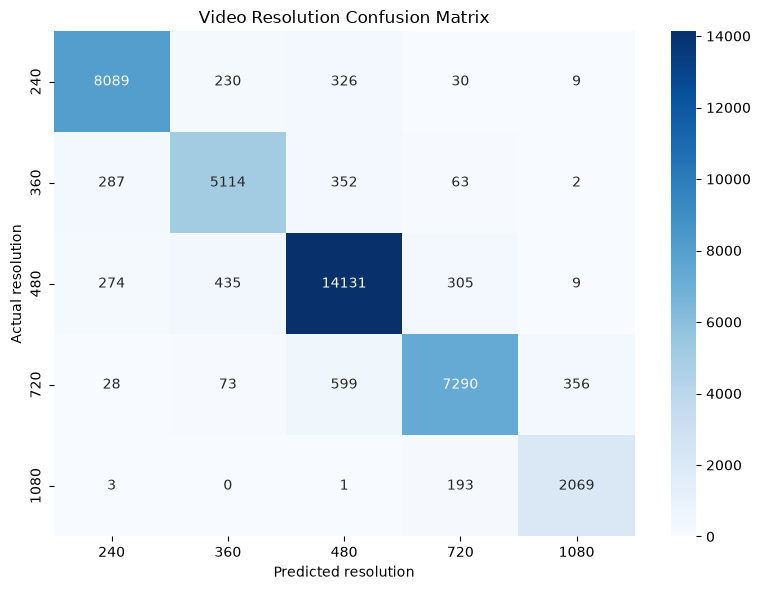

In [54]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

RESOLUTION_CLASSES = [240, 360, 480, 720, 1080]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=RESOLUTION_CLASSES
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=RESOLUTION_CLASSES,
    yticklabels=RESOLUTION_CLASSES
)

plt.xlabel("Predicted resolution")
plt.ylabel("Actual resolution")
plt.title("Video Resolution Confusion Matrix")
plt.tight_layout()
plt.show()

ROC/AUC

Macro ROC-AUC: 0.9911
Weighted ROC-AUC: 0.9900


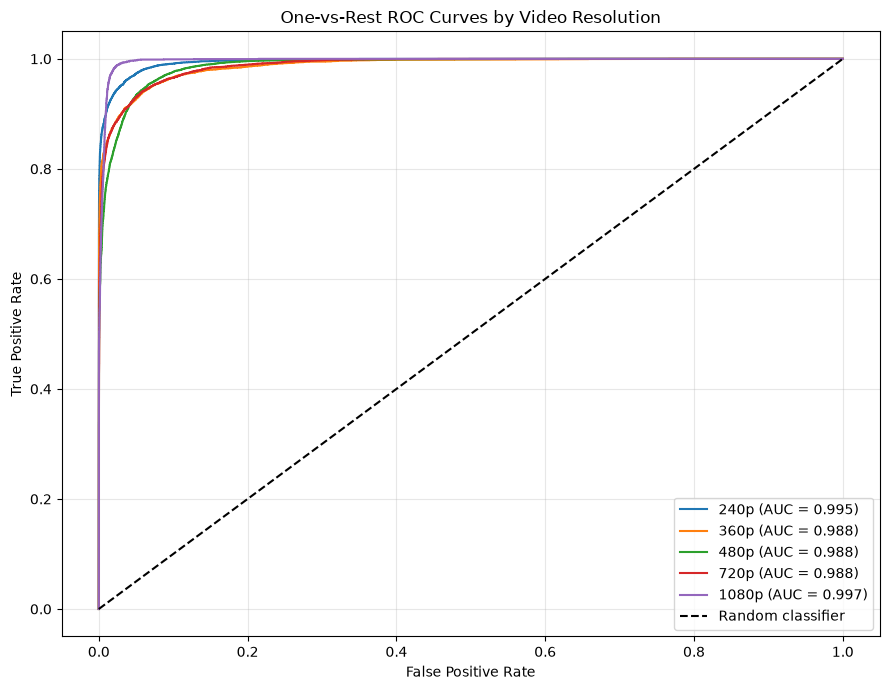

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize

model_classes = best_model.classes_
y_test_array = y_test.to_numpy()
y_probability = best_model.predict_proba(X_test)

y_test_binary = label_binarize(
    y_test_array,
    classes=model_classes
)

assert y_test_binary.shape == y_probability.shape

def binary_auc(y_true, scores):
    """
    Calculate binary ROC-AUC using the rank-sum formula.
    This correctly handles tied prediction scores.
    """
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)

    positive = y_true == 1
    negative = y_true == 0

    n_positive = positive.sum()
    n_negative = negative.sum()

    if n_positive == 0 or n_negative == 0:
        return np.nan

    ranks = pd.Series(scores).rank(
        method="average"
    ).to_numpy()

    positive_rank_sum = ranks[positive].sum()

    return (
        positive_rank_sum
        - n_positive * (n_positive + 1) / 2
    ) / (n_positive * n_negative)


def binary_roc_curve(y_true, scores):
    """Calculate points for a binary ROC curve."""
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)

    order = np.argsort(-scores, kind="mergesort")
    sorted_labels = y_true[order]
    sorted_scores = scores[order]

    true_positives = np.cumsum(sorted_labels == 1)
    false_positives = np.cumsum(sorted_labels == 0)

    distinct_indices = np.where(
        np.diff(sorted_scores)
    )[0]

    threshold_indices = np.concatenate([
        distinct_indices,
        [len(sorted_scores) - 1]
    ])

    true_positives = true_positives[threshold_indices]
    false_positives = false_positives[threshold_indices]

    true_positives = np.concatenate([[0], true_positives])
    false_positives = np.concatenate([[0], false_positives])

    positive_count = np.sum(y_true == 1)
    negative_count = np.sum(y_true == 0)

    true_positive_rate = true_positives / positive_count
    false_positive_rate = false_positives / negative_count

    return false_positive_rate, true_positive_rate


class_auc_values = []
class_support = []

plt.figure(figsize=(9, 7))

for class_index, resolution in enumerate(model_classes):
    binary_labels = y_test_binary[:, class_index]
    class_scores = y_probability[:, class_index]

    class_auc = binary_auc(
        binary_labels,
        class_scores
    )

    false_positive_rate, true_positive_rate = (
        binary_roc_curve(
            binary_labels,
            class_scores
        )
    )

    class_auc_values.append(class_auc)
    class_support.append(binary_labels.sum())

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{resolution}p (AUC = {class_auc:.3f})"
    )

macro_auc = np.nanmean(class_auc_values)

weighted_auc = np.average(
    class_auc_values,
    weights=class_support
)

print(f"Macro ROC-AUC: {macro_auc:.4f}")
print(f"Weighted ROC-AUC: {weighted_auc:.4f}")

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves by Video Resolution")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part 3: Predict the Ongoing Resolution of a Real Netflix Session

Now that you have your model, it's time to put it in practice!

Use a preprocessed Netflix video session to infer **and plot** the resolution at 10-second time intervals.

Selected Netflix Session ID: d8e6c15a3ae3e2805eb4ccaa1e552862
Session Windows: 66 (660 seconds)
Inferred Video Quality Trajectory:


,time_seconds,actual_resolution,predicted_resolution
0,0.0,360,480
1,10.0,360,720
2,20.0,360,480
3,30.0,480,480
4,40.0,480,480
5,50.0,480,480
6,60.0,480,480
7,70.0,480,480
8,80.0,480,480
9,90.0,480,480


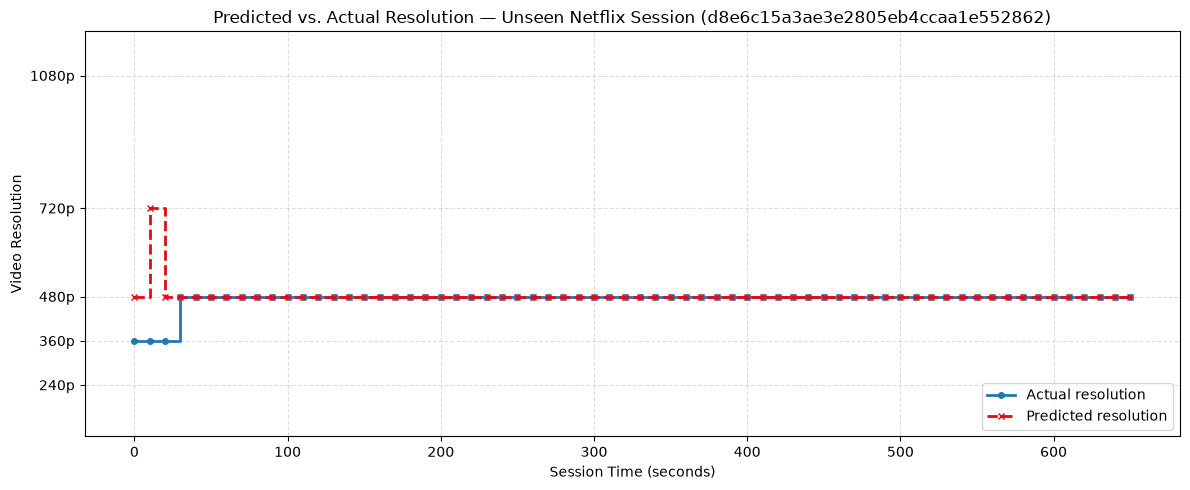

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

test_metadata = video_df.loc[groups_test.index]
netflix_test_mask = test_metadata["service"].str.lower() == "netflix"
netflix_test_ids = test_metadata.loc[netflix_test_mask, "session_id"]

if len(netflix_test_ids) == 0:
    raise ValueError("No Netflix sessions found in groups_test.")

example_session_id = netflix_test_ids.value_counts().index[0]

session_indices = groups_test[groups_test == example_session_id].index
session_indices = (
    video_df.loc[session_indices]
    .sort_values("relative_timestamp")
    .index
)

X_session = X_test.loc[session_indices]
y_session_true = y_test.loc[session_indices]

time_axis = video_df.loc[session_indices, "relative_timestamp"].to_numpy(dtype=float)
time_axis = time_axis - time_axis.min()

print(f"Selected Netflix Session ID: {example_session_id}")
print(f"Session Windows: {len(X_session)} ({len(X_session) * 10} seconds)")

assert list(X_session.columns) == list(X_train.columns)

predicted_resolution = best_model.predict(X_session)

results_df = pd.DataFrame({
    "time_seconds": time_axis,
    "actual_resolution": y_session_true.to_numpy(),
    "predicted_resolution": predicted_resolution
})

print("Inferred Video Quality Trajectory:")
display(results_df.head(10))

plt.figure(figsize=(12, 5))

plt.step(
    results_df["time_seconds"],
    results_df["actual_resolution"],
    where="post",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Actual resolution",
    color="#1f77b4"
)

plt.step(
    results_df["time_seconds"],
    results_df["predicted_resolution"],
    where="post",
    marker="x",
    markersize=5,
    linewidth=2,
    linestyle="--",
    label="Predicted resolution",
    color="#E50914"
)

VALID_RESOLUTIONS = [240, 360, 480, 720, 1080]
plt.yticks(VALID_RESOLUTIONS, [f"{r}p" for r in VALID_RESOLUTIONS])
plt.ylim(100, 1200)

plt.xlabel("Session Time (seconds)")
plt.ylabel("Video Resolution")
plt.title(f"Predicted vs. Actual Resolution — Unseen Netflix Session ({example_session_id})")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()